In [2]:
""" Carbon fluxes in Paul's observations """
import pandas as pd
import os
import numpy as np
import matplotlib.pyplot as plt
from utils.constants import *
from utils.paths import *
from utils.plotting import *
from utils.analysis import *
from scipy.stats import linregress, t

prefix_list = ['UQ_default2', 'UQ_root'] # 'UQ_default2_optimized'
N_list = [4000, 2000]
BLOCK = 200
VAR_LIST = ["ANPPtree", "ANPPshrub", "NPPmoss", "BGNPP", "NPP", "HR", "NEE"]

In [3]:
def get_obs():
    """ Get the observational slope & value at ambient chamber """
    plot_list = [f'P{p:02g}' for p in chamber_list_complete]

    obs_data = pd.read_excel(os.path.join(path_input, 'SPRUCE C Budget Summary 28Apr2022EXP.xlsx'), sheet_name = 'DataForPythonRead', skiprows = 1, engine = 'openpyxl')
    obs_data = obs_data.set_index(['Plot', 'Year']).sort_index(axis = 0)
    ## obs_data = pd.concat([obs_data, pd.DataFrame(np.nan, index = pd.MultiIndex.from_product([plot_list, [2015]]), columns = obs_data.columns)], axis = 0)
    obs_data = obs_data.sort_index()
    ## Do not use 2020 value
    ##obs_data.loc[(slice(None), 2020), :] = np.nan

    obs_data['NPP'] = obs_data['ANPP Tree (~48%C)'] + obs_data['ANPP Shrub (~50%C)'] + obs_data['BNPP Tree & Shrub'] + obs_data['NPP Sphag.']
    obs_data['ANPPtree'] = obs_data['ANPP Tree (~48%C)']
    obs_data['ANPPshrub'] = obs_data['ANPP Shrub (~50%C)']
    obs_data['NPPmoss'] = obs_data['NPP Sphag.']
    obs_data['BGNPP'] = obs_data['BNPP Tree & Shrub']
    obs_data['HR'] = obs_data['RHCO2']
    obs_data['NEE'] = obs_data['NCE'] # positive = coming out of the ecosystem

    t2m_obs = obs_data.loc[:, 'Mean Annual Temp. at 2 m']
    obs_data = obs_data.loc[:, VAR_LIST]

    collection = pd.DataFrame(np.nan,
                              index = pd.MultiIndex.from_product([VAR_LIST, ['amb', 'elev']]),
                              columns = ['mean', 'mean_std', 'slope', 'slope_std'])
    collection.index.names = ['Variable', 'CO2']

    for varname in VAR_LIST:
        for co2 in ['amb','elev']:
            if co2 == 'amb':
                filt = obs_data.index.get_level_values(0).isin([plot_list[0]] + plot_list[1::2])
            else:
                filt = obs_data.index.get_level_values(0).isin(plot_list[2::2])
            obs_temp = obs_data.loc[filt, varname]
            obs_T    = t2m_obs.loc[filt]

            res = linregress(obs_T, obs_temp)

            ts = abs(t.ppf(0.05, len(obs_T) - 2))

            collection.loc[(varname, co2), 'slope'] = res.slope
            collection.loc[(varname, co2), 'slope_std'] = ts * res.stderr

            obs_temp = obs_data.loc[obs_data.index.get_level_values(0) == plot_list[0], varname] # T0
            collection.loc[(varname, co2), 'mean'] = obs_temp.mean()
            collection.loc[(varname, co2), 'mean_std'] = obs_temp.std()

    return collection

In [4]:
# the dimensions are:
#   N sims x VAR_LIST x (amb, elev) x (mean, mean_std, slope, ts * slope_std)
collection_sim = {}


for N, prefix in zip(N_list, prefix_list):
    collect = np.empty([N, len(VAR_LIST), 2, 4], float)
    for b in range(0, N // BLOCK):
        collect[(b*BLOCK):((b + 1)*BLOCK), :, :] = np.load(os.path.join(path_out, "extract", prefix, f"ensemble_collection_part{b:03g}.bin"), allow_pickle=True)
    # convert Inf's to NaN
    collect = np.where(~((collect == np.inf) | (collect == -np.inf)), collect, np.nan)
    # convert unit from gC m-2 s-1 (per year) to gC m-2 (per year)
    collect = collect * 365 * 86400
    # revert the signs of NEE & HR to be compatible with Paul's data
    collect[:, 5:, :, :] = - collect[:, 5:, :, :]

    collection_sim[prefix] = collect

In [5]:
collection_obs = get_obs()
collection_obs

mean   mean_std      slope  slope_std
Variable  CO2                                              
ANPPtree  amb    81.533333  19.548367  -0.816665   3.341434
          elev   81.533333  19.548367  -0.338848   2.684829
ANPPshrub amb    77.389365  11.886258   5.314703   2.127957
          elev   77.389365  11.886258   8.823627   3.251274
NPPmoss   amb   129.583333  18.931077 -11.185588   2.819775
          elev  129.583333  18.931077  -7.533369   3.470893
BGNPP     amb    10.171875   0.435276   6.878300   1.919949
          elev   10.171875   0.435276  10.339268   2.485481
NPP       amb   298.677906  44.073694   0.190750   5.000575
          elev  298.677906  44.073694  11.290678   5.011837
HR        amb  -336.832272  26.006946 -21.632399   4.120561
          elev -336.832272  26.006946 -23.094001   4.183391
NEE       amb  -118.606698  84.013576 -36.874473  11.399360
          elev -118.606698  84.013576 -32.077410  10.644657

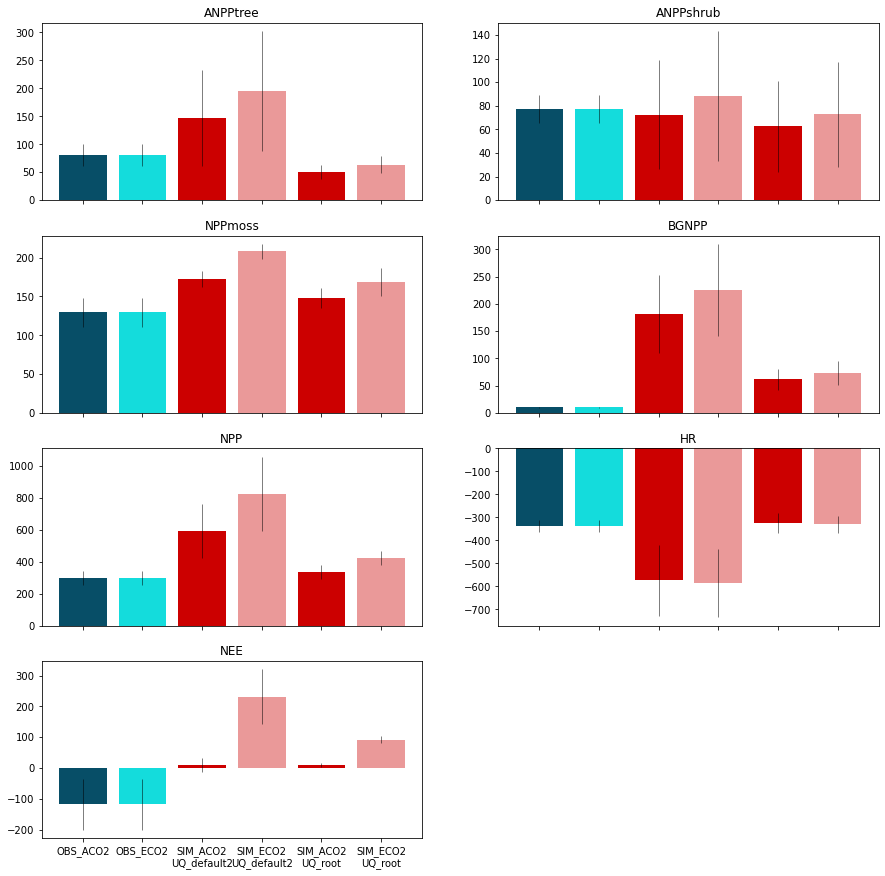

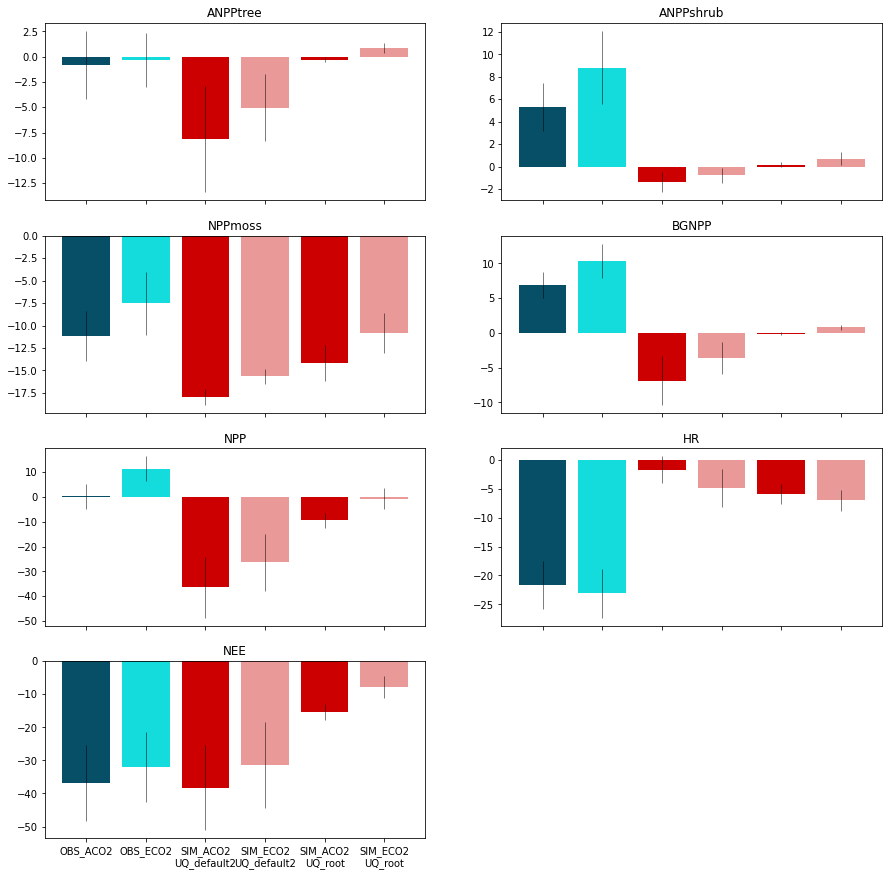

In [10]:
for quantity in ['mean', 'slope']:
    fig, axes = plt.subplots(4, 2, figsize = (15, 15), sharex = True, sharey = False)
    for i, ax in enumerate(axes.flat):
        if i >= len(VAR_LIST):
            ax.axis('off')
        else:
            varname = VAR_LIST[i]
            ax.bar([1, 2], collection_obs.loc[varname, quantity].values, color = ['#074e67', '#14dcdc'])
            ax.errorbar([1, 2], collection_obs.loc[varname, quantity].values, collection_obs.loc[varname, f'{quantity}_std'].values, 
                        ecolor = 'k', lw = 0, elinewidth = 0.5)
            ax.set_title(varname)

            if quantity == 'mean':
                k = 0
            else:
                k = 2

            for j, prefix in enumerate(prefix_list):
                temp = np.nanmean(collection_sim[prefix][:, i, :, k], axis = 0)
                temp_std = np.nanstd(collection_sim[prefix][:, i, :, k], axis = 0)

                ax.bar([3+j*2, 4+j*2], temp, color = ['#cc0000', '#ea9999'])
                ax.errorbar([3+j*2, 4+j*2], temp, temp_std, ecolor = 'k', lw = 0, elinewidth = 0.5)

        if i >= 5:
            ax.set_xticks(range(1, 3 + 2 * len(prefix_list)))
            ax.set_xticklabels(['OBS_ACO2', 'OBS_ECO2'] + [f'{a}\n{prefix}' for prefix in prefix_list for a in  ['SIM_ACO2', 'SIM_ECO2']])